In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("../data/FactSales_Anonymized.csv")
df.head()

,Date,Customer,Products,Quantity,Rate,Value ( Quantity * Rate )
0,04-Apr-24,ALDICA TECHNOLOGIES PRIVATE LIMITED,PRV BODY COMPONENT 47500010004,2000.0,78.90,157800.0
1,04-Apr-24,TECHNO SCIENCE INDUSTRIES,TECHNO SCIENCE COUPLING LOCKER,1025.0,20.00,20500.0
2,08-Apr-24,"SUPRAJIT ENGINEERING LIMITED, UNIT-9",ZINC SLEEVE SEL/102/592,8200.0,30.20,247640.0
3,08-Apr-24,"SUPRAJIT ENGINEERING LIMITED, UNIT-9",ROD-COM-00795,3000.0,7.04,21120.0
4,12-Apr-24,PUMA LIFT TRUCKS PRIVATE LIMITED,PUMA RELEASING ARM,500.0,32.40,16200.0


In [14]:
df = df.rename(columns={
    'Value ( Quantity * Rate )':'Revenue'
})
df.columns

Index(['Date', 'Customer', 'Products', 'Quantity', 'Rate', 'Revenue'], dtype='object')

In [15]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d-%b-%y'
)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1839 entries, 0 to 1838
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1839 non-null   datetime64[ns]
 1   Customer  1839 non-null   object        
 2   Products  1839 non-null   object        
 3   Quantity  1839 non-null   float64       
 4   Rate      1839 non-null   float64       
 5   Revenue   1839 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 86.3+ KB


In [17]:
#setup and validation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)

df['Date'] = pd.to_datetime(df['Date'])

print("Shape of dataset:", df.shape)
print("\nDate range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("\nUnique customers:", df['Customer'].nunique())
print("\nUnique products:", df['Products'].nunique())

df.head()

Shape of dataset: (1839, 6)

Date range: 2024-04-04 to 2026-06-30

Unique customers: 52

Unique products: 248


,Date,Customer,Products,Quantity,Rate,Revenue
0,2024-04-04,ALDICA TECHNOLOGIES PRIVATE LIMITED,PRV BODY COMPONENT 47500010004,"2,000.00",78.90,"157,800.00"
1,2024-04-04,TECHNO SCIENCE INDUSTRIES,TECHNO SCIENCE COUPLING LOCKER,"1,025.00",20.00,"20,500.00"
2,2024-04-08,"SUPRAJIT ENGINEERING LIMITED, UNIT-9",ZINC SLEEVE SEL/102/592,"8,200.00",30.20,"247,640.00"
3,2024-04-08,"SUPRAJIT ENGINEERING LIMITED, UNIT-9",ROD-COM-00795,"3,000.00",7.04,"21,120.00"
4,2024-04-12,PUMA LIFT TRUCKS PRIVATE LIMITED,PUMA RELEASING ARM,500.00,32.40,"16,200.00"


In [18]:
#setup and validation
key_cols = ['Date', 'Customer', 'Products', 'Quantity', 'Rate', 'Revenue']

print("Missing values per column:\n", df[key_cols].isnull().sum())

revenue_check = (df['Quantity'] * df['Rate']).round(2) == df['Revenue'].round(2)

print(
    "\nRows where Revenue = Quantity x Rate holds true:",
    revenue_check.sum(),
    "out of",
    len(df)
)

Missing values per column:
 Date        0
Customer    0
Products    0
Quantity    0
Rate        0
Revenue     0
dtype: int64

Rows where Revenue = Quantity x Rate holds true: 1838 out of 1839


In [19]:
#RFM Analysis
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)

print(
    "Snapshot date used for Recency calculation:",
    snapshot_date.date()
)

rfm = df.groupby('Customer').agg(
    Recency=('Date',
             lambda x:
             (snapshot_date - x.max()).days),

    Frequency=('Date', 'nunique'),

    Monetary=('Revenue', 'sum')
).reset_index()

rfm.sort_values(
    'Monetary',
    ascending=False
).head(10)

Snapshot date used for Recency calculation: 2026-07-01


,Customer,Recency,Frequency,Monetary
49,TEKNIC EUCHNER ELECTRONICS PVT LTD,2,116,"14,342,668.06"
19,KEMS AUTO COMPONENTS LTD - UNIT II,2,81,"11,619,804.30"
4,APEX LUMINAIRES PRIVATE LIMITED,4,68,"9,863,788.26"
3,ALDICA TECHNOLOGIES PRIVATE LIMITED,4,74,"9,392,517.00"
43,"SUPRAJIT ENGINEERING LIMITED, UNIT-9",25,57,"8,240,681.20"
5,ARVIND TOOLS,4,47,"3,098,950.30"
20,KEMS SHAKTI PRECISION CASTINGS PVT LTD,7,14,"2,703,005.00"
27,PLASMET SYSTEMS,47,10,"2,604,695.00"
36,SNS ENTERPRISES,338,11,"2,143,940.00"
34,ROTARY ELECTRONICS PVT LTD UNIT-2,151,30,"1,874,380.00"


In [20]:
#RFM Analysis
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
).astype(int)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
).astype(int)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
).astype(int)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    +
    rfm['F_Score'].astype(str)
    +
    rfm['M_Score'].astype(str)
)

rfm.head(10)

,Customer,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,AARDING INDIA PVT LTD,139,4,"430,417.00",3,3,3,333
1,AAWISHKAR,210,4,"117,090.00",2,3,2,232
2,ACELION ENERGY STORAGE SOLUTION PRIVATE LIMITED,67,4,"997,658.85",3,3,3,333
3,ALDICA TECHNOLOGIES PRIVATE LIMITED,4,74,"9,392,517.00",4,4,4,444
4,APEX LUMINAIRES PRIVATE LIMITED,4,68,"9,863,788.26",4,4,4,444
5,ARVIND TOOLS,4,47,"3,098,950.30",4,4,4,444
6,ATPS ENGINEERING PRIVATE LIMITED,120,2,"162,000.00",3,2,2,322
7,DEEYEM CNC MACHINING PVT LTD,1,21,"611,673.00",4,4,3,443
8,ESBEE PRECISION INDUSTRIES,303,43,"1,415,144.00",2,4,4,244
9,EXCEL DIE CASTERS,324,1,"163,250.00",2,1,2,212


In [21]:
#RFM Analysis
def assign_segment(row):

    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'

    elif row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customers'

    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'

    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost Customers'

    else:
        return 'Potential / Others'

rfm['Segment'] = rfm.apply(
    assign_segment,
    axis=1
)

In [22]:
#RFM Analysis
segment_summary = rfm.groupby(
    'Segment'
).agg(
    Customers=('Customer', 'count'),
    Total_Revenue=('Monetary', 'sum')
)

segment_summary

,Customers,Total_Revenue
Segment,,
At Risk,2,"302,090.00"
Champions,6,"56,558,409.12"
Lost Customers,17,"1,867,145.03"
Loyal Customers,16,"21,007,795.75"
Potential / Others,11,"1,995,062.08"


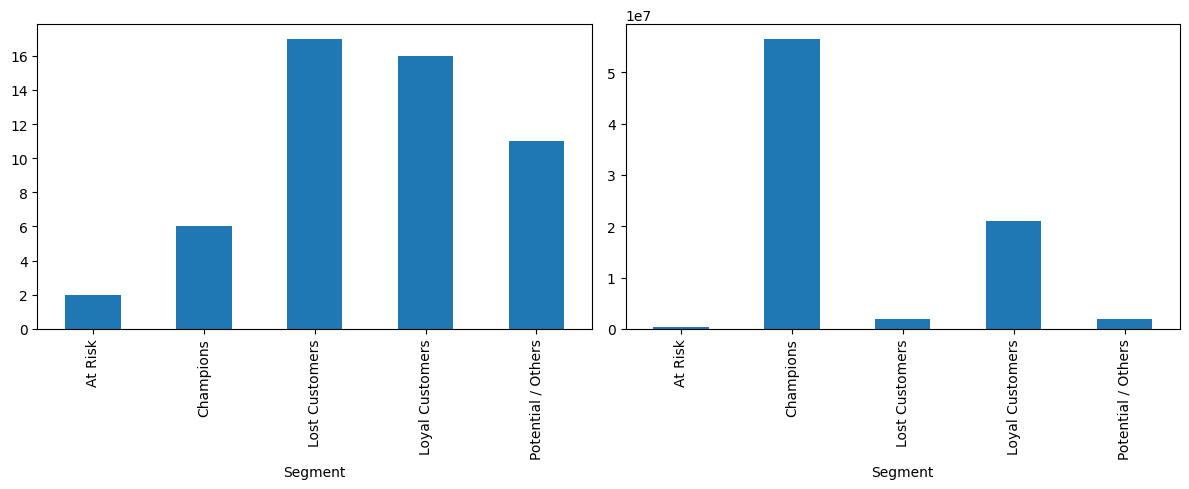

In [43]:
#RFM Analysis
fig, axes = plt.subplots(1,2,figsize=(12,5))

segment_summary['Customers'].plot(
    kind='bar',
    ax=axes[0]
)

segment_summary['Total_Revenue'].plot(
    kind='bar',
    ax=axes[1]
)

plt.tight_layout()
plt.savefig("../outputs/RFM_Segments.png", bbox_inches="tight")
plt.show()

In [24]:
#Pareto Analysis
cust_rev = (
    df.groupby('Customer')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

cust_rev['Revenue_%'] = (
    cust_rev['Revenue']
    /
    cust_rev['Revenue'].sum()
) * 100

cust_rev['Cumulative_%'] = (
    cust_rev['Revenue_%']
    .cumsum()
)

cust_rev.head(10)

,Customer,Revenue,Revenue_%,Cumulative_%
0,TEKNIC EUCHNER ELECTRONICS PVT LTD,"14,342,668.06",17.55,17.55
1,KEMS AUTO COMPONENTS LTD - UNIT II,"11,619,804.30",14.22,31.77
2,APEX LUMINAIRES PRIVATE LIMITED,"9,863,788.26",12.07,43.83
3,ALDICA TECHNOLOGIES PRIVATE LIMITED,"9,392,517.00",11.49,55.33
4,"SUPRAJIT ENGINEERING LIMITED, UNIT-9","8,240,681.20",10.08,65.41
5,ARVIND TOOLS,"3,098,950.30",3.79,69.20
6,KEMS SHAKTI PRECISION CASTINGS PVT LTD,"2,703,005.00",3.31,72.51
7,PLASMET SYSTEMS,"2,604,695.00",3.19,75.70
8,SNS ENTERPRISES,"2,143,940.00",2.62,78.32
9,ROTARY ELECTRONICS PVT LTD UNIT-2,"1,874,380.00",2.29,80.61


In [25]:
#Pareto Analysis
customers_to_80 = cust_rev[
    cust_rev['Cumulative_%'] <= 80
]

num_customers_80 = len(customers_to_80) + 1

pct_of_customer_base = (
    num_customers_80
    /
    len(cust_rev)
) * 100

print(
    f"Customers needed to reach 80% of total revenue: {num_customers_80}"
)

print(
    f"That is {pct_of_customer_base:.1f}% of the customer base."
)

Customers needed to reach 80% of total revenue: 10
That is 19.2% of the customer base.


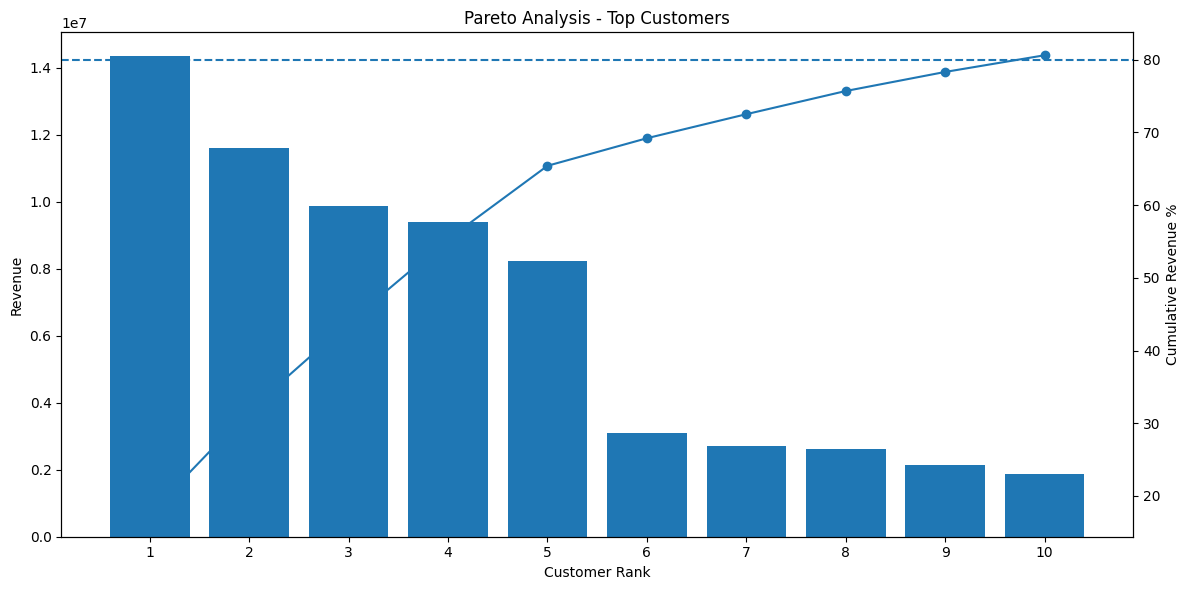

In [47]:
#Pareto Analysis
fig, ax1 = plt.subplots(figsize=(12,6))

top_n = 10
plot_data = cust_rev.head(top_n).copy()

plot_data['Rank'] = range(1, top_n + 1)

# Revenue bars
ax1.bar(
    plot_data['Rank'],
    plot_data['Revenue']
)

ax1.set_xlabel('Customer Rank')
ax1.set_ylabel('Revenue')
ax1.set_title('Pareto Analysis - Top Customers')

# Cumulative percentage line
ax2 = ax1.twinx()

ax2.plot(
    plot_data['Rank'],
    plot_data['Cumulative_%'],
    marker='o'
)

ax2.axhline(
    y=80,
    linestyle='--'
)

ax2.set_ylabel('Cumulative Revenue %')

plt.xticks(plot_data['Rank'])

plt.tight_layout()
plt.savefig("../outputs/Pareto_Chart.png", bbox_inches="tight")
plt.show()

In [27]:
#ABC Classification
prod_rev = (
    df.groupby('Products')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

prod_rev['Revenue_%'] = (
    prod_rev['Revenue']
    /
    prod_rev['Revenue'].sum()
) * 100

prod_rev['Cumulative_%'] = (
    prod_rev['Revenue_%']
    .cumsum()
)

prod_rev.head(10)

,Products,Revenue,Revenue_%,Cumulative_%
0,PRV BODY COMPONENT 47500010004,"7,672,715.50",9.39,9.39
1,Pannier Stay RH R101050239,"5,793,382.15",7.09,16.48
2,Pannier Stay LH R101050238,"5,793,382.15",7.09,23.56
3,APX/H51-2-250 CG BOX BOTTOM PLATE WITH RAW MAT...,"4,316,958.61",5.28,28.85
4,ZINC SLEEVE SEL/102/592,"3,923,122.70",4.80,33.65
5,YOKE-CLAMP 645,"2,146,109.65",2.63,36.27
6,SNS EJECTOR BODY RH & LH CASTINGS,"2,101,940.00",2.57,38.84
7,APEX TRIANGLE BOLLARD PCB COVER WITH RAW MATERIAL,"1,951,136.32",2.39,41.23
8,D1 HEAD 5204605 (PDC-MACHINED),"1,912,399.40",2.34,43.57
9,D2 HEAD (PDC-MACHINING),"1,886,663.00",2.31,45.88


In [28]:
#ABC Classification
def classify_abc(cum_pct):

    if cum_pct <= 70:
        return 'A'

    elif cum_pct <= 90:
        return 'B'

    else:
        return 'C'

prod_rev['ABC_Class'] = (
    prod_rev['Cumulative_%']
    .apply(classify_abc)
)

In [29]:
#ABC Classification
abc_summary = prod_rev.groupby(
    'ABC_Class'
).agg(
    Products=('Products','count'),
    Total_Revenue=('Revenue','sum')
)

abc_summary

,Products,Total_Revenue
ABC_Class,,
A,29,"56,730,680.47"
B,58,"16,761,956.52"
C,161,"8,237,864.99"


In [30]:
#COHORT Analysis
df['Transaction_Month'] = (
    df['Date'].dt.to_period('M')
)

df['Cohort_Month'] = (
    df.groupby('Customer')['Date']
      .transform('min')
      .dt.to_period('M')
)

In [31]:
#COHORT Analysis
def month_diff(row):

    return (
        (row['Transaction_Month'].year
         -
         row['Cohort_Month'].year) * 12
        +
        (row['Transaction_Month'].month
         -
         row['Cohort_Month'].month)
    )

df['Cohort_Index'] = df.apply(
    month_diff,
    axis=1
)

In [32]:
#COHORT Analysis
cohort_data = (
    df.groupby(
        ['Cohort_Month',
         'Cohort_Index']
    )['Customer']
     .nunique()
     .reset_index()
)

cohort_counts = cohort_data.pivot(
    index='Cohort_Month',
    columns='Cohort_Index',
    values='Customer'
)

cohort_counts.head()

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26
Cohort_Month,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-04,8.00,5.00,5.00,5.00,4.00,3.00,4.00,3.00,3.00,4.00,3.00,3.00,3.00,4.00,3.00,3.00,3.00,2.00,3.00,3.00,4.00,3.00,4.00,4.00,4.00,5.00,3.00
2024-05,7.00,3.00,4.00,3.00,2.00,2.00,1.00,2.00,3.00,1.00,2.00,1.00,1.00,2.00,NaN,1.00,2.00,1.00,2.00,1.00,3.00,2.00,1.00,2.00,1.00,2.00,NaN
2024-07,5.00,1.00,2.00,2.00,2.00,1.00,2.00,1.00,1.00,1.00,1.00,1.00,NaN,1.00,1.00,1.00,NaN,1.00,1.00,1.00,1.00,1.00,1.00,1.00,NaN,NaN,NaN
2024-08,4.00,3.00,2.00,3.00,2.00,1.00,1.00,1.00,2.00,2.00,1.00,2.00,1.00,2.00,1.00,2.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,NaN,NaN,NaN,NaN
2024-09,1.00,NaN,1.00,NaN,NaN,1.00,NaN,NaN,NaN,1.00,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
#COHORT Analysis
cohort_size = cohort_counts.iloc[:,0]

retention_matrix = (
    cohort_counts.divide(
        cohort_size,
        axis=0
    ) * 100
)

retention_matrix.round(1)

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26
Cohort_Month,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-04,100.00,62.50,62.50,62.50,50.00,37.50,50.00,37.50,37.50,50.00,37.50,37.50,37.50,50.00,37.50,37.50,37.50,25.00,37.50,37.50,50.00,37.50,50.00,50.00,50.00,62.50,37.50
2024-05,100.00,42.90,57.10,42.90,28.60,28.60,14.30,28.60,42.90,14.30,28.60,14.30,14.30,28.60,NaN,14.30,28.60,14.30,28.60,14.30,42.90,28.60,14.30,28.60,14.30,28.60,NaN
2024-07,100.00,20.00,40.00,40.00,40.00,20.00,40.00,20.00,20.00,20.00,20.00,20.00,NaN,20.00,20.00,20.00,NaN,20.00,20.00,20.00,20.00,20.00,20.00,20.00,NaN,NaN,NaN
2024-08,100.00,75.00,50.00,75.00,50.00,25.00,25.00,25.00,50.00,50.00,25.00,50.00,25.00,50.00,25.00,50.00,50.00,50.00,25.00,25.00,25.00,25.00,25.00,NaN,NaN,NaN,NaN
2024-09,100.00,NaN,100.00,NaN,NaN,100.00,NaN,NaN,NaN,100.00,NaN,NaN,100.00,NaN,NaN,NaN,NaN,NaN,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-10,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11,100.00,50.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01,100.00,50.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


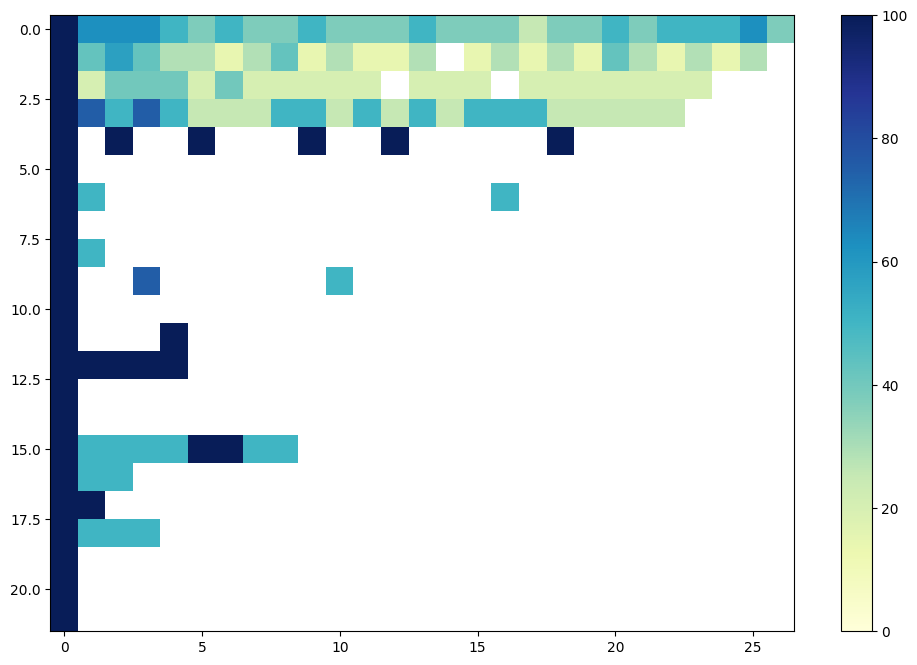

In [45]:
#COHORT Analysis
fig, ax = plt.subplots(
    figsize=(12,8)
)

data = retention_matrix.values

im = ax.imshow(
    data,
    cmap='YlGnBu',
    aspect='auto',
    vmin=0,
    vmax=100
)

plt.colorbar(im)
plt.savefig("../outputs/Cohort_Heatmap.png", bbox_inches="tight")
plt.show()

In [37]:
rfm.to_csv("../outputs/RFM_Output.csv", index=False)

print("RFM saved")

RFM saved


In [38]:
cust_rev.to_csv("../outputs/Pareto_Output.csv", index=False)

print("Pareto saved")

Pareto saved


In [40]:
prod_rev.to_csv("../outputs/ABC_Output.csv", index=False)

print("ABC saved")

ABC saved


In [41]:
retention_matrix.to_csv("../outputs/Cohort_Output.csv")

print("Cohort saved")

Cohort saved


In [46]:
import os

os.listdir()

['.ipynb_checkpoints',
 'ABC_Output.csv',
 'Cohort_Heatmap.png',
 'Cohort_Output.csv',
 'FactSales.csv',
 'Manufacturing_Sales_Analytics.ipynb',
 'Pareto_Chart.png',
 'Pareto_Output.csv',
 'RFM_Output.csv',
 'RFM_Segments.png']